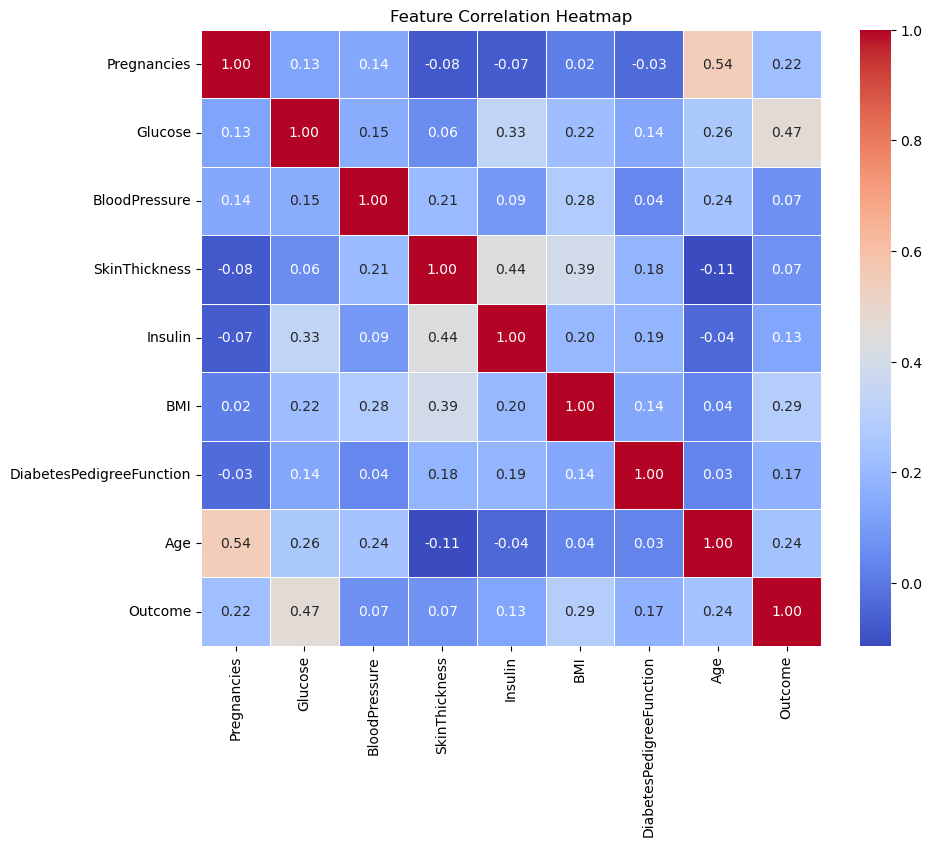

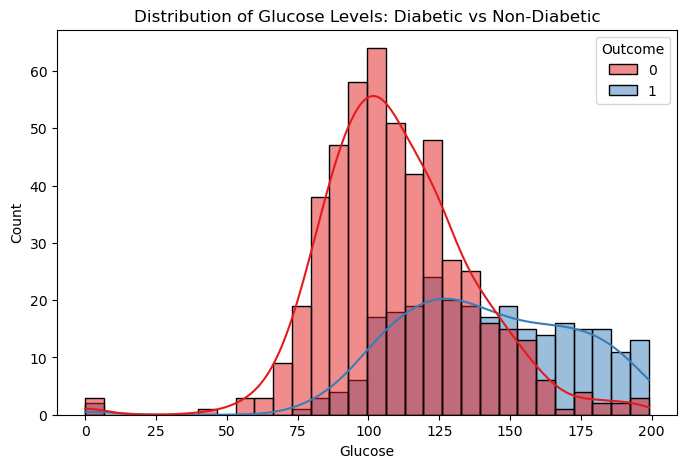

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('diabetes-k-nn.csv')

# GRAPH 1: Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show() # <-- Take your first screenshot here!

# GRAPH 2: Glucose Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True, palette='Set1', bins=30)
plt.title('Distribution of Glucose Levels: Diabetic vs Non-Diabetic')
plt.show() # <-- Take your second screenshot here!

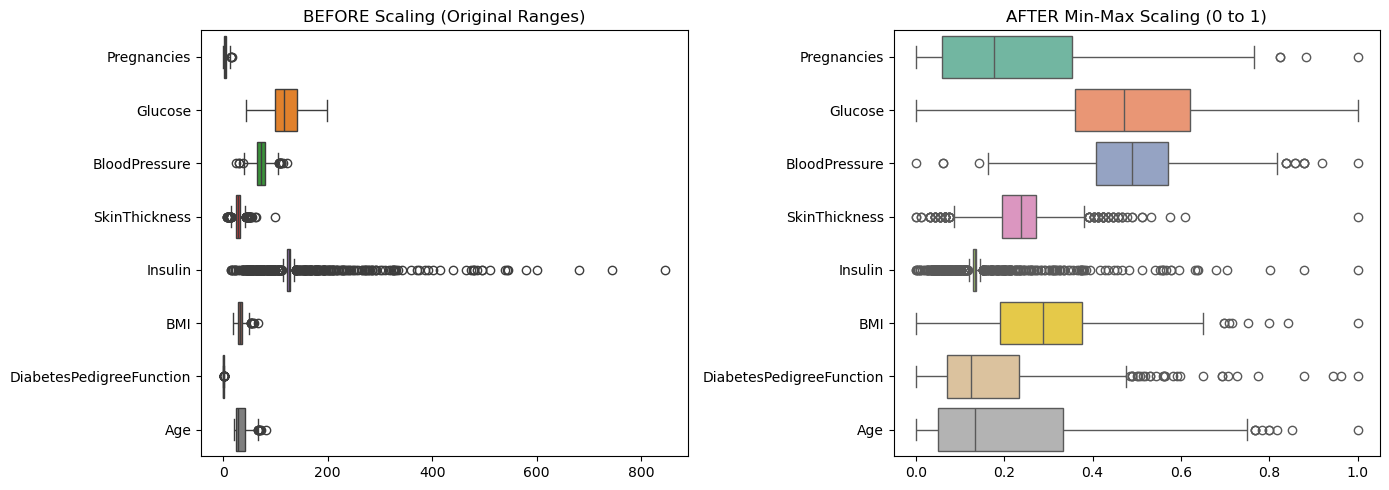

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Fix the missing zeros
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_impute] = df[cols_to_impute].replace(0, np.nan)
df[cols_to_impute] = df[cols_to_impute].fillna(df[cols_to_impute].median())

# Scale the data
scaler = MinMaxScaler()
X = df.drop('Outcome', axis=1) 
y = df['Outcome']              
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# GRAPH 3: Before & After Scaling Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df.drop('Outcome', axis=1), ax=axes[0], orient='h')
axes[0].set_title('BEFORE Scaling (Original Ranges)')

sns.boxplot(data=X_scaled_df, ax=axes[1], orient='h', palette='Set2')
axes[1].set_title('AFTER Min-Max Scaling (0 to 1)')

plt.tight_layout()
plt.show() # <-- Take your third screenshot here!

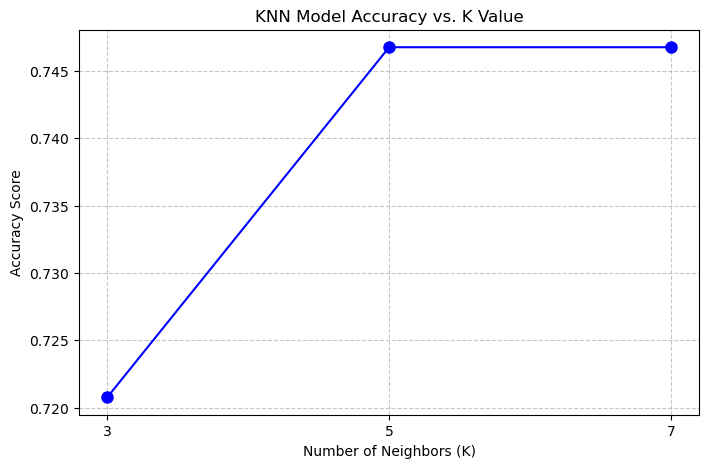

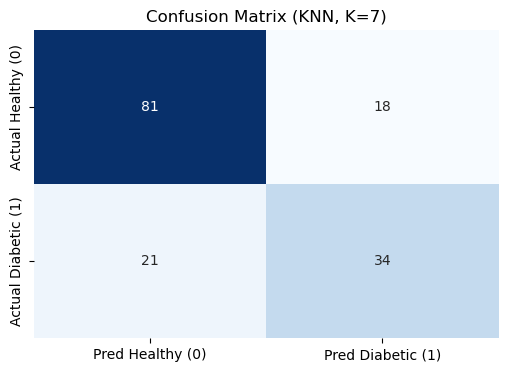

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)

k_values = [3, 5, 7]
accuracies = []
best_cm = None

# Train the models
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))
    if k == 7: 
        best_cm = confusion_matrix(y_test, y_pred) # Save this for the graph

# GRAPH 4: Accuracy vs K Value
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b', markersize=8)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Score')
plt.title('KNN Model Accuracy vs. K Value')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show() # <-- Take your fourth screenshot here!

# GRAPH 5: Visual Confusion Matrix (for K=7)
plt.figure(figsize=(6, 4))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Pred Healthy (0)', 'Pred Diabetic (1)'],
            yticklabels=['Actual Healthy (0)', 'Actual Diabetic (1)'])
plt.title('Confusion Matrix (KNN, K=7)')
plt.show() # <-- Take your fifth and final screenshot here!